# Dense Linear Probe: Pixel-Level Cardiac Segmentation with DINOv3 on ACDC

This notebook trains a **dense linear probe** for semantic segmentation of cardiac MRI slices,
following the DINOv3 paper's linear evaluation protocol (Appendix D.1), on the
ACDC dataset (100 train / 50 test patients).

**Architecture**: Frozen DINOv3 ViT-S/16 backbone → feature extraction →
Dropout2d → BatchNorm2d → per-pixel 1×1 Conv2d → bilinear upsample (4 classes: BG, RV, MYO, LV).

This matches the official DINOv3 `LinearHead`: features are classified at **patch resolution**
(12×12), then upsampled to full resolution. A trained BatchNorm layer normalises features before the
linear classifier, following the paper's protocol.

**What the notebook does**:
1. Loads the ACDC dataset and splits training patients into train/val (stratified by pathology)
2. Caches multi-layer frozen backbone features to disk (4 evenly-spaced layers)
3. Trains a dense linear probe on the cached features using **Dice + CrossEntropy** loss
4. Evaluates per-class and per-patient Dice scores on the held-out test set
5. Visualises pixel-level predictions vs ground truth
6. Saves the trained probe head

**Configurable layer selection**: by default only the **last layer** is used (matching paper D.1),
but all 4 cached layers can be used by setting `USE_LAYERS = LAYER_INDICES`.

**Development backbone**: `dinov3_vits16` (~21M params) — lightweight for MacBook Pro.
To swap to `dinov3_vitb16` or `dinov3_vitl16`, change `MODEL_NAME` and re-run feature caching.

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cinema.segmentation.dataset import EndDiastoleEndSystoleDataset
from monai.transforms import ScaleIntensityd
from torch.utils.data import DataLoader
from tqdm import tqdm

from heartfm_evals.dense_linear_probe import (
    CLASS_COLORS,
    CLASS_NAMES,
    IMAGE_SIZE,
    MODEL_CONFIGS,
    NUM_CLASSES,
    CachedFeatureDataset,
    CombinedLoss,
    DenseLinearProbe,
    cache_features,
    dice_score,
    evaluate,
    overlay_labels,
    train_one_epoch,
)

In [2]:
# ── Paths ──
ACDC_DATA_DIR = Path("/Users/lbokeria/projects/health_gc/data/heartfm/processed/acdc")
REPO_DIR = "../../models/dinov3/"

# ── Backbone selection (change here to swap) ──
MODEL_NAME = "dinov3_vits16"  # lightweight for dev; swap to dinov3_vitb16 for final
WEIGHTS_PATH = f"../../model_weights/{MODEL_NAME}.pth"
EMBED_DIM = MODEL_CONFIGS[MODEL_NAME]["embed_dim"]  # 384 for vits16
N_LAYERS = MODEL_CONFIGS[MODEL_NAME]["n_layers"]     # 12

# ── Feature extraction layers (cached to disk) ──
LAYER_INDICES = (3, 6, 9, 11)  # 4 evenly-spaced layers cached for flexibility

# ── Layers used by the probe (subset of LAYER_INDICES) ──
# Default: last layer only, matching DINOv3 paper D.1 protocol.
# Change to LAYER_INDICES to use all 4 cached layers.
USE_LAYERS = (11,)

# ── Cache directory (per backbone) ──
CACHE_DIR = Path(f"../../feature_cache/{MODEL_NAME}")

# ── Training ──
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-3
DROPOUT = 0.1
N_EPOCHS = 20
PATIENCE = 10

# ── Device ──
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")
print(f"Backbone: {MODEL_NAME} (embed_dim={EMBED_DIM}, layers={N_LAYERS})")
print(f"Cached layers: {LAYER_INDICES} → cache dim = {EMBED_DIM * len(LAYER_INDICES)}")
print(f"Probe layers:  {USE_LAYERS} → probe input dim = {EMBED_DIM * len(USE_LAYERS)}")

Using device: mps
Backbone: dinov3_vits16 (embed_dim=384, layers=12)
Cached layers: (3, 6, 9, 11) → cache dim = 1536
Probe layers:  (11,) → probe input dim = 384


## 2. Load ACDC Data (Full Dataset)

In [3]:
train_meta_df = pd.read_csv(ACDC_DATA_DIR / "train_metadata.csv")
test_meta_df = pd.read_csv(ACDC_DATA_DIR / "test_metadata.csv")

print(f"Full training set: {len(train_meta_df)} patients")
print(f"Full test set:     {len(test_meta_df)} patients")
if "pathology" in train_meta_df.columns:
    print(f"\nPathology distribution (train):\n{train_meta_df['pathology'].value_counts().to_string()}")

Full training set: 100 patients
Full test set:     50 patients

Pathology distribution (train):
pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20


### Train / Validation Split

Stratified by pathology: 2 patients per group held out for validation
(10 val / 90 train), following the CineMA convention.

In [4]:
if "pathology" in train_meta_df.columns:
    val_pids = (
        train_meta_df.groupby("pathology")
        .sample(n=2, random_state=0)["pid"]
        .tolist()
    )
else:
    # Fallback: random 10% if pathology column is missing
    val_pids = train_meta_df.sample(frac=0.1, random_state=0)["pid"].tolist()

train_split_df = train_meta_df[~train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)
val_split_df = train_meta_df[train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)

print(f"Train split: {len(train_split_df)} patients")
print(f"Val split:   {len(val_split_df)} patients")
print(f"Test set:    {len(test_meta_df)} patients")
print(f"\nVal patient IDs: {val_pids}")

Train split: 90 patients
Val split:   10 patients
Test set:    50 patients

Val patient IDs: ['patient019', 'patient002', 'patient032', 'patient022', 'patient056', 'patient054', 'patient079', 'patient061', 'patient088', 'patient082']


In [5]:
transform = ScaleIntensityd(keys="sax_image", factor=1 / 255, channel_wise=False)

train_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=train_split_df,
    views="sax",
    transform=transform,
)

val_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=val_split_df,
    views="sax",
    transform=transform,
)

test_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "test",
    meta_df=test_meta_df,
    views="sax",
    transform=transform,
)

print(f"Train CineMA dataset: {len(train_cinema)} samples")
print(f"Val CineMA dataset:   {len(val_cinema)} samples")
print(f"Test CineMA dataset:  {len(test_cinema)} samples")

Train CineMA dataset: 180 samples
Val CineMA dataset:   20 samples
Test CineMA dataset:  100 samples


## 3. Load Backbone and Cache Features

Since the backbone is **frozen**, we pre-extract features once and cache to disk.
This avoids re-running the ViT every epoch and makes training very fast (~6K trainable params).

In [6]:
backbone = torch.hub.load(REPO_DIR, MODEL_NAME, source="local", weights=WEIGHTS_PATH)
backbone.eval()
backbone.to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False
print(f"Loaded {MODEL_NAME} with {sum(p.numel() for p in backbone.parameters()):,} parameters (frozen)")

Loaded dinov3_vits16 with 21,601,152 parameters (frozen)


In [7]:
print("Caching training features...")
train_manifest = cache_features(
    backbone, train_cinema, CACHE_DIR / "train",
    layer_indices=LAYER_INDICES, device=DEVICE,
)

print("\nCaching validation features...")
val_manifest = cache_features(
    backbone, val_cinema, CACHE_DIR / "val",
    layer_indices=LAYER_INDICES, device=DEVICE,
)

print("\nCaching test features...")
test_manifest = cache_features(
    backbone, test_cinema, CACHE_DIR / "test",
    layer_indices=LAYER_INDICES, device=DEVICE,
)

print(f"\nCached: {len(train_manifest)} train, {len(val_manifest)} val, {len(test_manifest)} test slices")

Caching training features...


Caching features: 100%|██████████| 180/180 [00:11<00:00, 16.08it/s]



Caching validation features...


Caching features: 100%|██████████| 20/20 [00:01<00:00, 15.03it/s]



Caching test features...


Caching features: 100%|██████████| 100/100 [00:06<00:00, 15.32it/s]


Cached: 1534 train, 178 val, 916 test slices


In [8]:
# Verify cached feature shapes
sample = torch.load(train_manifest[0]["path"], weights_only=True)
print(f"Feature shape: {sample['features'].shape}")  # expect (embed_dim*len(LAYER_INDICES), 12, 12)
print(f"Label shape:   {sample['label'].shape}")      # expect (192, 192)

expected_cache_channels = EMBED_DIM * len(LAYER_INDICES)
assert sample["features"].shape[0] == expected_cache_channels, (
    f"Expected {expected_cache_channels} cached channels, got {sample['features'].shape[0]}"
)
print(f"Cache shape check passed! (probe will select {EMBED_DIM * len(USE_LAYERS)} channels for layers {USE_LAYERS})")

Feature shape: torch.Size([1536, 12, 12])
Label shape:   torch.Size([192, 192])
Cache shape check passed! (probe will select 384 channels for layers (11,))


## 4. Create DataLoaders

In [9]:
train_ds = CachedFeatureDataset(train_manifest)
val_ds = CachedFeatureDataset(val_manifest)
test_ds = CachedFeatureDataset(test_manifest)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} slices, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} slices, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} slices, {len(test_loader)} batches")

Train: 1534 slices, 96 batches
Val:   178 slices, 12 batches
Test:  916 slices, 58 batches


## 5. Define Model, Loss, Optimizer

In [10]:
probe = DenseLinearProbe(
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    layer_indices=USE_LAYERS,
    cached_layers=LAYER_INDICES,
    dropout=DROPOUT,
).to(DEVICE)

criterion = CombinedLoss(ce_weight=1.0, dice_weight=1.0)
optimizer = torch.optim.AdamW(probe.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

n_params = sum(p.numel() for p in probe.parameters() if p.requires_grad)
print(f"Dense linear probe: {n_params:,} trainable parameters (includes BN + Conv)")
print(f"Loss: CE + Dice")
print(f"Optimizer: AdamW (lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealing (T_max={N_EPOCHS})")

Dense linear probe: 2,308 trainable parameters (includes BN + Conv)
Loss: CE + Dice
Optimizer: AdamW (lr=0.001, wd=0.001)
Scheduler: CosineAnnealing (T_max=20)


## 6. Training Loop

In [11]:
best_val_dice = 0.0
best_epoch = 0
epochs_no_improve = 0
history = {"train_loss": [], "val_macro_dice": [], "lr": []}

for epoch in range(1, N_EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(probe, train_loader, criterion, optimizer, DEVICE)
    scheduler.step()

    # Validate
    val_metrics = evaluate(probe, val_loader, DEVICE)
    val_dice = val_metrics["macro_dice"]

    # Record
    history["train_loss"].append(train_loss)
    history["val_macro_dice"].append(val_dice)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    # Print every 5 epochs or on improvement
    improved = val_dice > best_val_dice
    if epoch % 5 == 0 or epoch == 1 or improved:
        tag = " *" if improved else ""
        print(
            f"Epoch {epoch:3d}/{N_EPOCHS} | "
            f"loss={train_loss:.4f} | "
            f"val Dice={val_dice:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}{tag}"
        )

    # Early stopping
    if improved:
        best_val_dice = val_dice
        best_epoch = epoch
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val Dice={best_val_dice:.4f} at epoch {best_epoch}.")
            break

# Restore best model
probe.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch} (val Dice={best_val_dice:.4f})")

Epoch   1/20 | loss=1.5930 | val Dice=0.6657 | lr=9.94e-04 *
Epoch   2/20 | loss=0.7242 | val Dice=0.6995 | lr=9.76e-04 *
Epoch   3/20 | loss=0.5783 | val Dice=0.7149 | lr=9.46e-04 *
Epoch   4/20 | loss=0.5347 | val Dice=0.7247 | lr=9.05e-04 *
Epoch   5/20 | loss=0.5102 | val Dice=0.7305 | lr=8.54e-04 *
Epoch   6/20 | loss=0.4929 | val Dice=0.7370 | lr=7.94e-04 *
Epoch   7/20 | loss=0.4894 | val Dice=0.7403 | lr=7.27e-04 *
Epoch   8/20 | loss=0.4831 | val Dice=0.7430 | lr=6.55e-04 *
Epoch   9/20 | loss=0.4707 | val Dice=0.7441 | lr=5.78e-04 *
Epoch  10/20 | loss=0.4652 | val Dice=0.7448 | lr=5.00e-04 *
Epoch  11/20 | loss=0.4639 | val Dice=0.7474 | lr=4.22e-04 *
Epoch  12/20 | loss=0.4575 | val Dice=0.7490 | lr=3.45e-04 *
Epoch  13/20 | loss=0.4571 | val Dice=0.7508 | lr=2.73e-04 *
Epoch  15/20 | loss=0.4589 | val Dice=0.7501 | lr=1.46e-04
Epoch  16/20 | loss=0.4542 | val Dice=0.7515 | lr=9.55e-05 *
Epoch  19/20 | loss=0.4513 | val Dice=0.7524 | lr=6.16e-06 *
Epoch  20/20 | loss=0.4474

### Training Curves

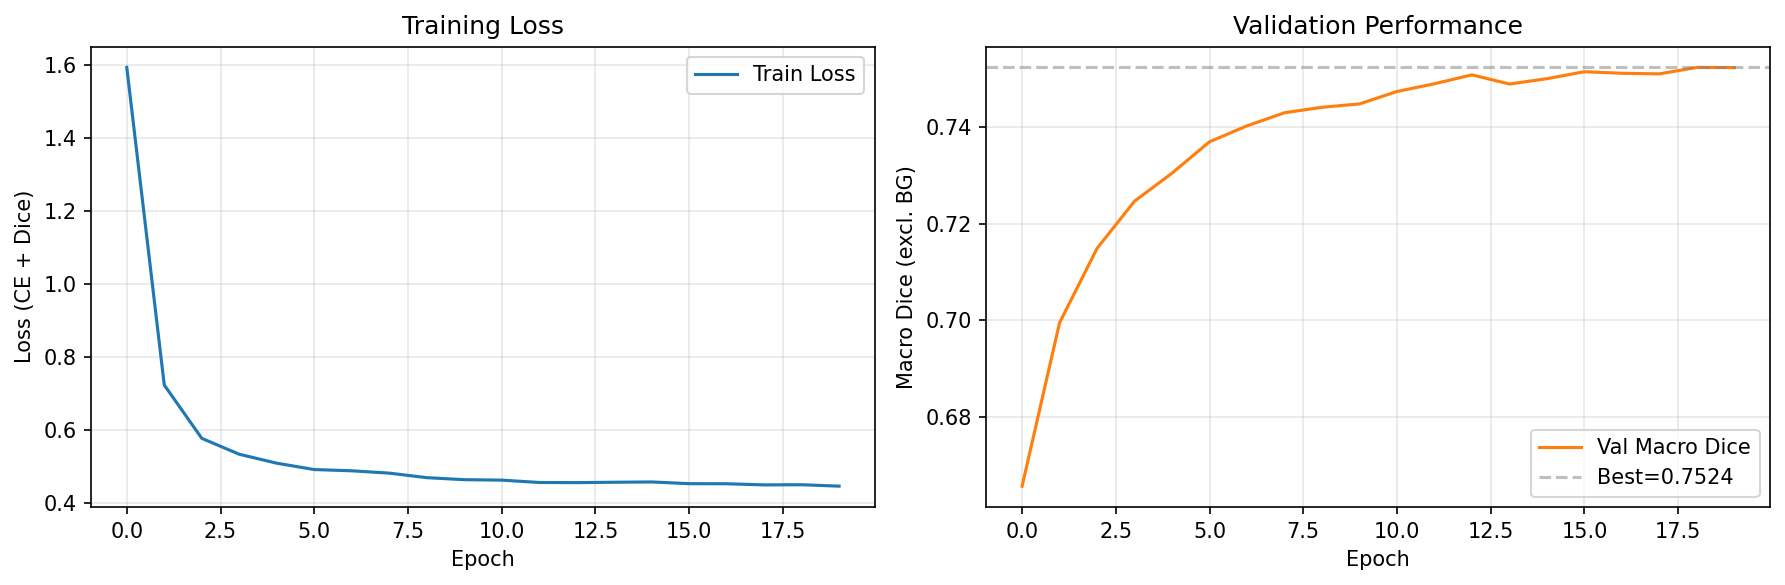

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

ax1.plot(history["train_loss"], label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (CE + Dice)")
ax1.set_title("Training Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_macro_dice"], label="Val Macro Dice", color="tab:orange")
ax2.axhline(best_val_dice, ls="--", color="gray", alpha=0.5, label=f"Best={best_val_dice:.4f}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro Dice (excl. BG)")
ax2.set_title("Validation Performance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test Set Evaluation

In [13]:
test_metrics = evaluate(probe, test_loader, DEVICE)

print("Per-class Dice scores (test set):")
for name, d in test_metrics["per_class_dice"].items():
    print(f"  {name:>3s}: {d:.4f}")
print(f"\nMacro Dice (excl. BG): {test_metrics['macro_dice']:.4f}")

Per-class Dice scores (test set):
   BG: 0.9815
   RV: 0.7252
  MYO: 0.6594
   LV: 0.8419

Macro Dice (excl. BG): 0.7422


### Per-Patient Dice Scores

In [14]:
# Compute Dice per patient for a clinical breakdown
from heartfm_evals.dense_linear_probe import macro_dice as compute_macro_dice

patient_dices = []

probe.eval()
with torch.inference_mode():
    for i, entry in enumerate(test_manifest):
        data = torch.load(entry["path"], weights_only=True)
        feats = data["features"].unsqueeze(0).to(DEVICE)
        label = data["label"].numpy()

        logits = probe(feats)
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        patient_dices.append({
            "pid": entry["pid"],
            "z_idx": entry["z_idx"],
            "macro_dice": compute_macro_dice(pred, label),
            **{CLASS_NAMES[c]: dice_score(pred, label, c) for c in range(NUM_CLASSES)},
        })

dice_df = pd.DataFrame(patient_dices)
patient_summary = dice_df.groupby("pid")[["macro_dice", "RV", "MYO", "LV"]].mean()
print("Per-patient mean Macro Dice (test set):")
print(patient_summary.round(4).to_string())
print(f"\nOverall mean ± std: {patient_summary['macro_dice'].mean():.4f} ± {patient_summary['macro_dice'].std():.4f}")

Per-patient mean Macro Dice (test set):
            macro_dice      RV     MYO      LV
pid                                           
patient101      0.6115  0.4411  0.6055  0.7878
patient102      0.4459  0.4407  0.4777  0.4194
patient103      0.6016  0.2752  0.6879  0.8416
patient104      0.5063  0.3494  0.6307  0.5390
patient105      0.4867  0.3844  0.5782  0.4976
patient106      0.6706  0.7622  0.3991  0.8505
patient107      0.4349  0.3849  0.3374  0.5826
patient108      0.4729  0.3798  0.5365  0.5026
patient109      0.6634  0.6993  0.5597  0.7310
patient110      0.5475  0.5418  0.5189  0.5818
patient111      0.6245  0.3447  0.7649  0.7638
patient112      0.5824  0.4400  0.4998  0.8075
patient113      0.6392  0.5160  0.5948  0.8070
patient114      0.5240  0.2723  0.6113  0.6884
patient115      0.5673  0.4730  0.5081  0.7210
patient116      0.5462  0.3707  0.5916  0.6763
patient117      0.6311  0.5005  0.5309  0.8621
patient118      0.6205  0.5236  0.5781  0.7597
patient119      0.60

## 8. Visualization — Pixel-Level Predictions

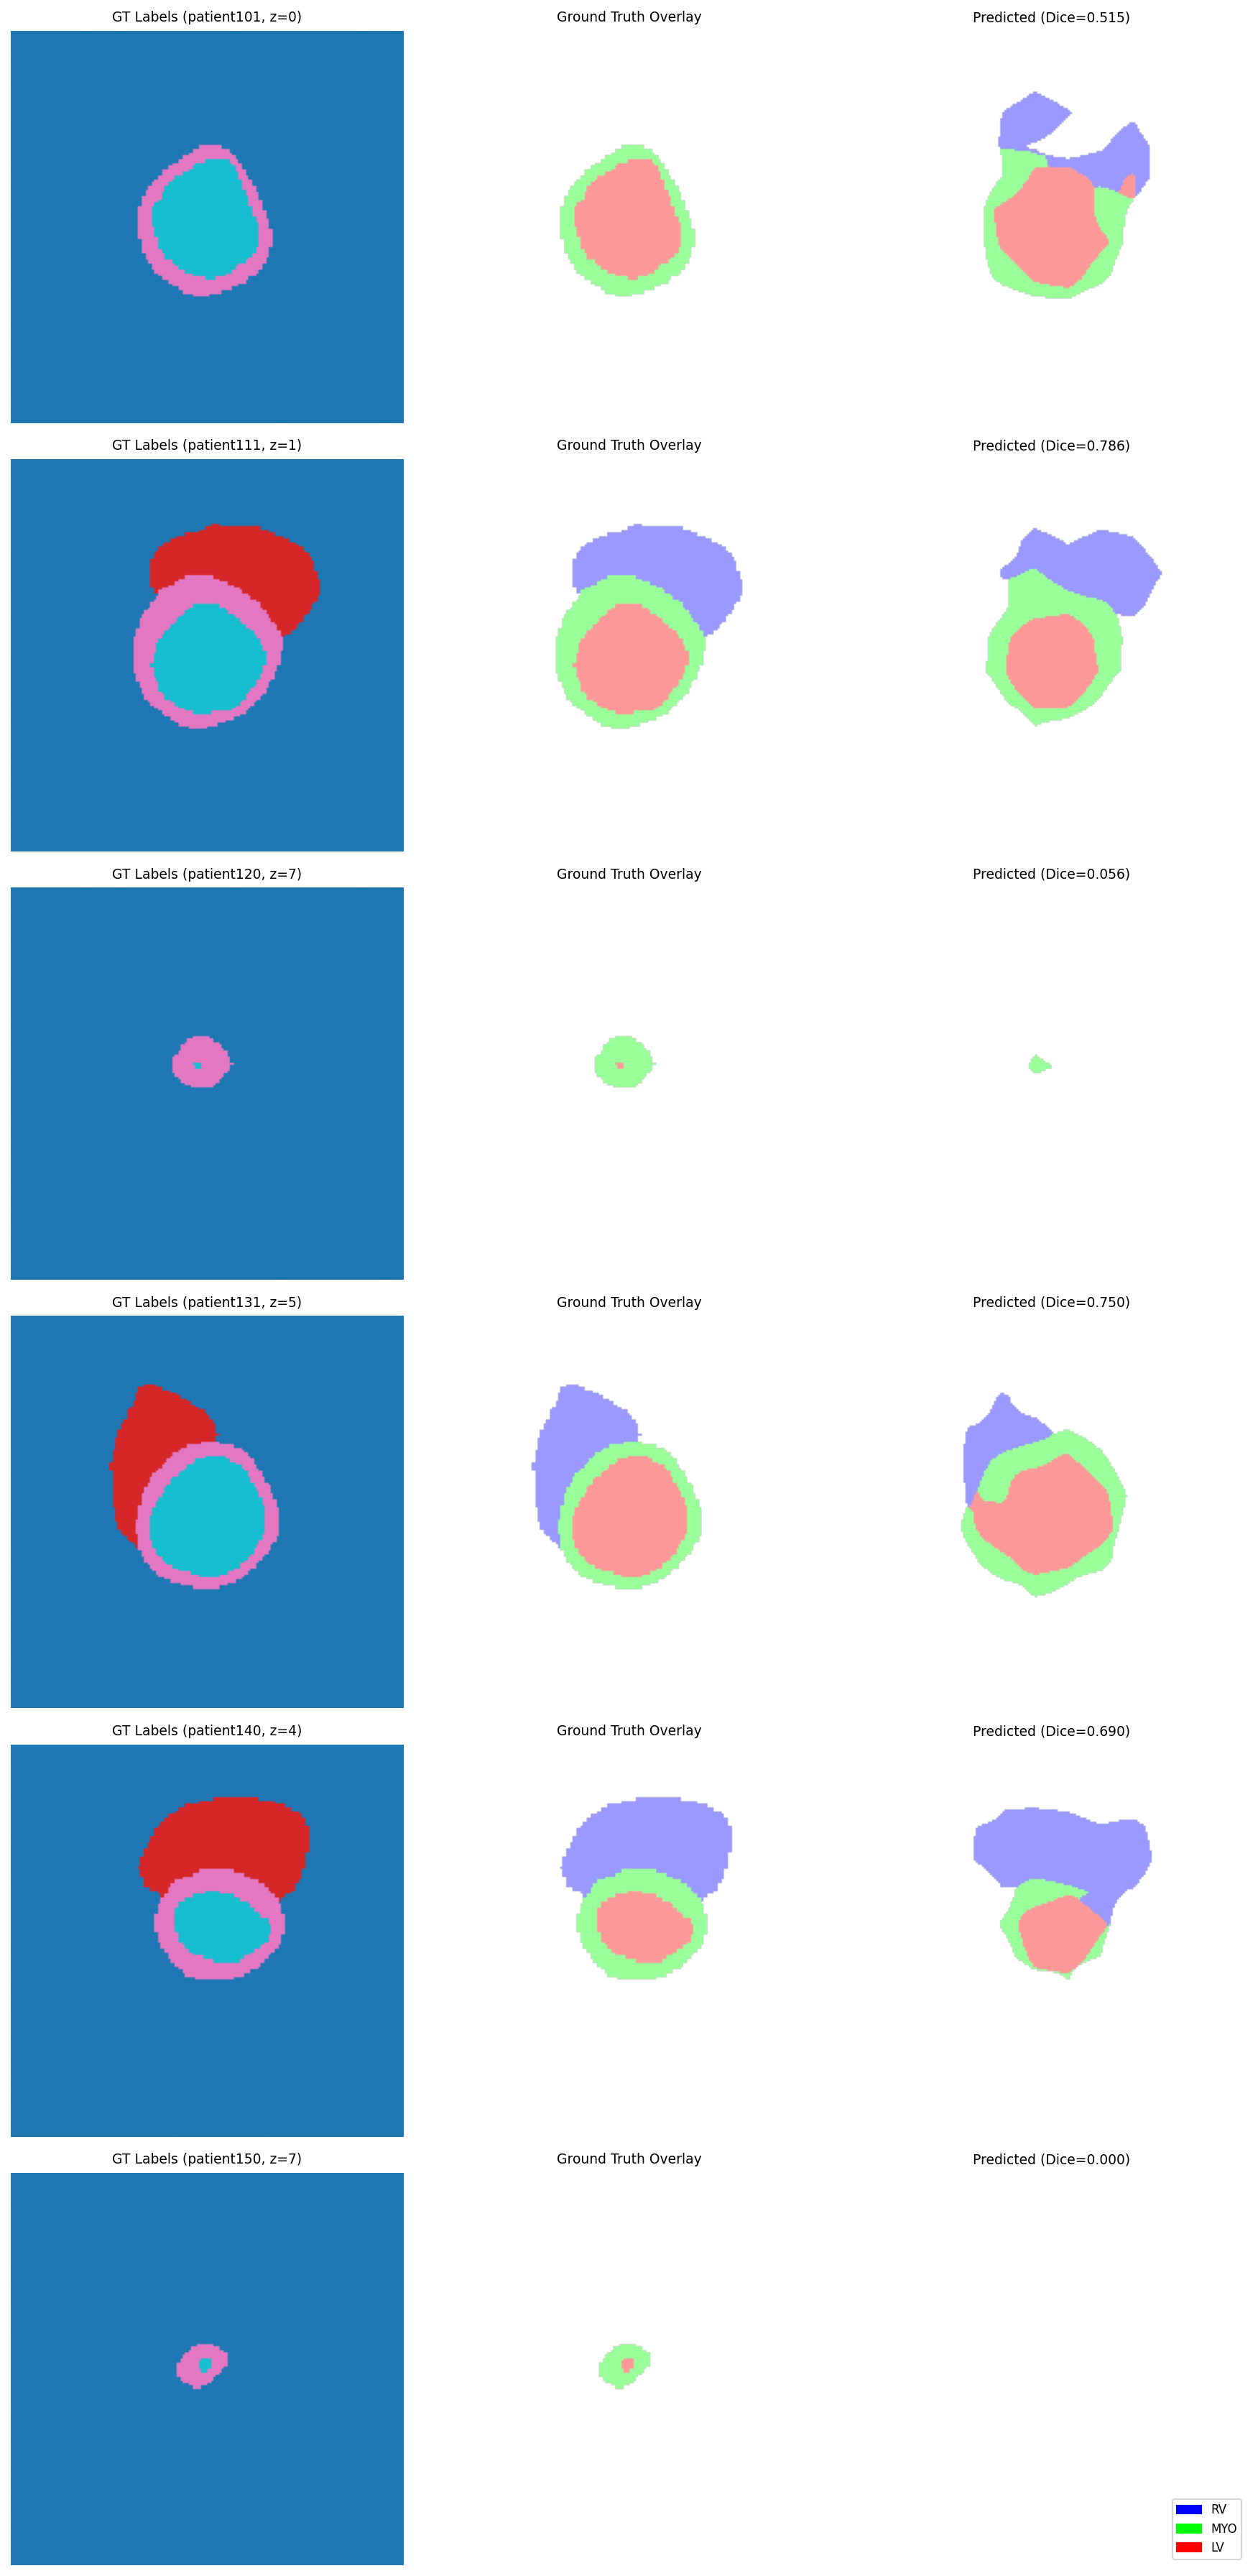

In [15]:
# Pick 6 evenly-spaced test slices for visualization
n_show = min(6, len(test_manifest))
show_indices = np.linspace(0, len(test_manifest) - 1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show), dpi=150)
if n_show == 1:
    axes = axes[np.newaxis, :]

probe.eval()
with torch.inference_mode():
    for row, idx in enumerate(show_indices):
        entry = test_manifest[idx]
        data = torch.load(entry["path"], weights_only=True)
        feats = data["features"].unsqueeze(0).to(DEVICE)
        label = data["label"].numpy()

        logits = probe(feats)
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        # Load original image for display
        # Reconstruct from the CineMA test dataset
        gt_overlay = overlay_labels(label, IMAGE_SIZE, IMAGE_SIZE)
        pred_overlay = overlay_labels(pred, IMAGE_SIZE, IMAGE_SIZE)

        # Show label as grayscale proxy (since cached features don't store raw image)
        axes[row, 0].imshow(label, cmap="tab10", vmin=0, vmax=3)
        axes[row, 0].set_title(f"GT Labels ({entry['pid']}, z={entry['z_idx']})", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_overlay)
        axes[row, 1].set_title("Ground Truth Overlay", fontsize=9)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_overlay)
        axes[row, 2].set_title(f"Predicted (Dice={compute_macro_dice(pred, label):.3f})", fontsize=9)
        axes[row, 2].axis("off")

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[c][:3] + (1.0,), label=CLASS_NAMES[c])
    for c in range(1, NUM_CLASSES)
]
axes[-1, 2].legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Save Model

In [16]:
save_path = Path(f"../dense_probe_{MODEL_NAME}.pt")
torch.save(
    {
        "model_state_dict": probe.state_dict(),
        "model_name": MODEL_NAME,
        "embed_dim": EMBED_DIM,
        "layer_indices": LAYER_INDICES,
        "num_classes": NUM_CLASSES,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "test_metrics": test_metrics,
        "val_pids": val_pids,
    },
    save_path,
)
print(f"Model saved to {save_path}")

Model saved to ../dense_probe_dinov3_vits16.pt
